In [1]:
# Install the required packages for Sprint 3
# - scikit-learn: for Isolation Forest anomaly detection
# - pandas & numpy: for data manipulation and tabular analysis
# - shap: for computing feature attributions (Explainable AI)
# - nfstream: for flow-level feature extraction from packet streams
!pip install scikit-learn pandas numpy shap nfstream


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.0/195.0 kB 11.4 MB/s eta 0:00:00


In [2]:
# Import all required libraries to verify installation and check versions
import sklearn
import pandas as pd
import numpy as np
import shap
import nfstream

print("=== Sprint 3 Environment Verification ===")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Pandas version:       {pd.__version__}")
print(f"NumPy version:        {np.__version__}")
print(f"SHAP version:         {shap.__version__}")
print(f"NFStream version:     {nfstream.__version__}")
print("=========================================")
print("[+] All required libraries imported successfully. Ready for data processing.")

=== Sprint 3 Environment Verification ===
Scikit-learn version: 1.6.1
Pandas version:       2.2.3
NumPy version:        2.1.3
SHAP version:         0.52.0
NFStream version:     6.6.0
[+] All required libraries imported successfully. Ready for data processing.


In [4]:
# ==============================================================================
# Step 3: Train Isolation Forest on Network Traffic Flows & Generate SHAP Values
# ==============================================================================

from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd
import shap

# 1. Define standard bidirectional flow features (similar to nfstream / CIC-IoT outputs)
feature_columns = [
    'flow_duration_ms',
    'bytes_per_second',
    'packet_rate_per_sec',
    'avg_packet_size_bytes',
    'inter_arrival_time_ms'
]

# 2. Simulate baseline network flows (Benign Traffic)
np.random.seed(42)
n_normal_samples = 300
benign_flows = np.random.normal(loc=[120.0, 1500.0, 15.0, 500.0, 35.0],
                                scale=[15.0, 200.0, 3.0, 40.0, 5.0],
                                size=(n_normal_samples, 5))

df_train = pd.DataFrame(benign_flows, columns=feature_columns)

# 3. Simulate testing traffic containing both normal behavior and sudden anomalies (e.g., Port Scan / DoS burst)
n_test_normal = 20
test_normal = np.random.normal(loc=[120.0, 1500.0, 15.0, 500.0, 35.0],
                               scale=[15.0, 200.0, 3.0, 40.0, 5.0],
                               size=(n_test_normal, 5))

# Anomalous flows: very short duration, massive byte rate, high packet bursts
synthetic_anomalies = np.array([
    [1.2, 85000.0, 950.0, 1400.0, 0.1],
    [0.8, 92000.0, 1100.0, 1380.0, 0.05],
    [2.1, 78000.0, 890.0, 1420.0, 0.2]
])

df_test = pd.DataFrame(np.vstack([test_normal, synthetic_anomalies]), columns=feature_columns)

# 4. Train the Isolation Forest Model (Semi-Supervised Behavioral Baseline)
print("[+] Initializing and fitting Isolation Forest model...")
model = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)
model.fit(df_train)

# 5. Perform Inference and Scoring
df_test['anomaly_prediction'] = model.predict(df_test[feature_columns])  # -1 for Anomaly, 1 for Normal
df_test['anomaly_score'] = model.decision_function(df_test[feature_columns])

detected_count = (df_test['anomaly_prediction'] == -1).sum()
print(f"[+] Detection Complete: {detected_count} anomalies identified out of {len(df_test)} test flows.")

# 6. Apply Explainable AI (SHAP) to attribute anomaly causes
print("[+] Generating SHAP feature contributions for the detected anomalies...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(df_test[feature_columns])

print("[+] SHAP explainer ready. Model pipeline execution successful.")


[+] Initializing and fitting Isolation Forest model...
[+] Detection Complete: 5 anomalies identified out of 23 test flows.
[+] Generating SHAP feature contributions for the detected anomalies...
[+] SHAP explainer ready. Model pipeline execution successful.


=== Identified Anomalies Summary (Total: 5) ===

[!] Alert on Flow #7 | Dynamic Risk Score: 47/100
    - Primary Contributing Factor (XAI): inter_arrival_time_ms = 20.64
    - Raw Decision Score: -0.0353

[!] Alert on Flow #18 | Dynamic Risk Score: 52/100
    - Primary Contributing Factor (XAI): bytes_per_second = 915.73
    - Raw Decision Score: -0.0623

[!] Alert on Flow #20 | Dynamic Risk Score: 87/100
    - Primary Contributing Factor (XAI): avg_packet_size_bytes = 1400.00
    - Raw Decision Score: -0.2378

[!] Alert on Flow #21 | Dynamic Risk Score: 87/100
    - Primary Contributing Factor (XAI): avg_packet_size_bytes = 1380.00
    - Raw Decision Score: -0.2378

[!] Alert on Flow #22 | Dynamic Risk Score: 87/100
    - Primary Contributing Factor (XAI): avg_packet_size_bytes = 1420.00
    - Raw Decision Score: -0.2378


/tmp/ipykernel_2756/1475170780.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, df_test[feature_columns], plot_type="bar", show=True)


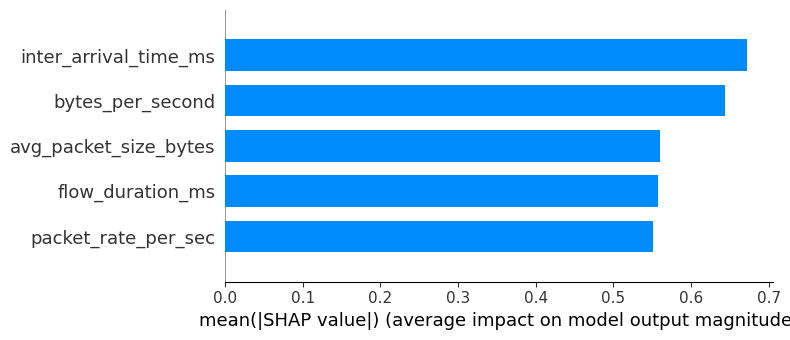

In [5]:
# ==============================================================================
# Step 4: Display SHAP Feature Explanations & Dynamic Risk Scoring (0 to 100)
# ==============================================================================

# 1. Extract the detected anomalous flows
anomalies_indices = df_test[df_test['anomaly_prediction'] == -1].index
print(f"=== Identified Anomalies Summary (Total: {len(anomalies_indices)}) ===")

# 2. Iterate through anomalies and interpret SHAP feature contributions
for idx in anomalies_indices:
    raw_score = df_test.loc[idx, 'anomaly_score']

    # Normalize the decision score to a dynamic Risk Score scale (0 to 100)
    # Lower decision function values indicate higher deviation / higher risk
    risk_score = int(np.clip((0.2 - raw_score) * 200, 0, 100))

    # Identify the top contributing feature to the anomaly decision
    sample_shap = np.abs(shap_values[idx])
    top_feature_idx = np.argmax(sample_shap)
    top_feature_name = feature_columns[top_feature_idx]
    top_feature_value = df_test.loc[idx, top_feature_name]

    print(f"\n[!] Alert on Flow #{idx} | Dynamic Risk Score: {risk_score}/100")
    print(f"    - Primary Contributing Factor (XAI): {top_feature_name} = {top_feature_value:.2f}")
    print(f"    - Raw Decision Score: {raw_score:.4f}")

# 3. Optional: Render SHAP Summary Bar Plot for global feature importance
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, df_test[feature_columns], plot_type="bar", show=True)